# Метрики бинарной классификации

Покажем, как порог решения меняет precision, recall и F1, и сравним ROC-кривую с Precision-Recall-кривой на несбалансированных данных.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    f1_score,
    precision_recall_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

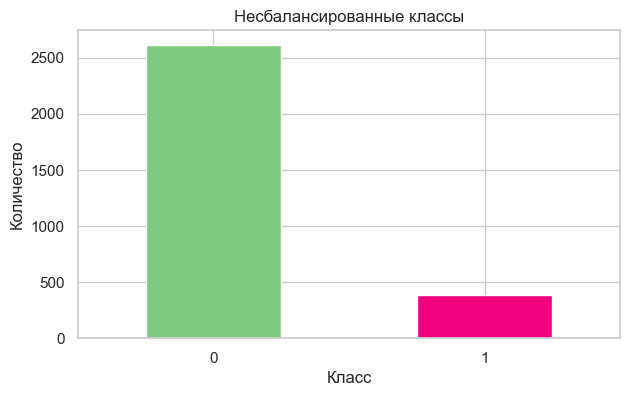

In [2]:
features, target = make_classification(
    n_samples=3000,
    n_features=16,
    n_informative=7,
    n_redundant=3,
    weights=[0.88, 0.12],
    class_sep=1.1,
    flip_y=0.02,
    random_state=42,
)
train_features, test_features, train_target, test_target = train_test_split(
    features, target, test_size=0.3, random_state=42, stratify=target
)

pd.Series(target).value_counts().sort_index().plot.bar(figsize=(7, 4), color=["#7fc97f", "#f0027f"])
plt.title("Несбалансированные классы")
plt.xlabel("Класс")
plt.ylabel("Количество")
plt.xticks(rotation=0)
plt.show()

In [3]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=3000, random_state=42)),
])
model.fit(train_features, train_target)
probability = model.predict_proba(test_features)[:, 1]

precision, recall, thresholds = precision_recall_curve(test_target, probability)
f1_values = 2 * precision[:-1] * recall[:-1] / np.maximum(precision[:-1] + recall[:-1], 1e-12)
threshold_frame = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1],
    "f1": f1_values,
})
best_row = threshold_frame.loc[threshold_frame["f1"].idxmax()]
best_row.to_frame("value")

,value
threshold,0.266475
precision,0.656250
recall,0.724138
f1,0.688525


## Метрики при разных порогах

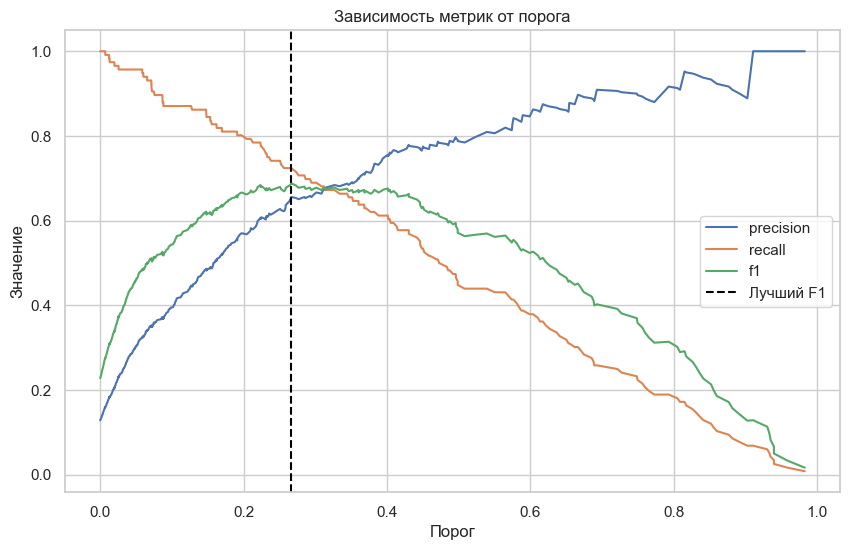

In [4]:
plt.figure(figsize=(10, 6))
for metric in ["precision", "recall", "f1"]:
    plt.plot(threshold_frame["threshold"], threshold_frame[metric], label=metric)
plt.axvline(best_row["threshold"], linestyle="--", color="black", label="Лучший F1")
plt.title("Зависимость метрик от порога")
plt.xlabel("Порог")
plt.ylabel("Значение")
plt.legend()
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


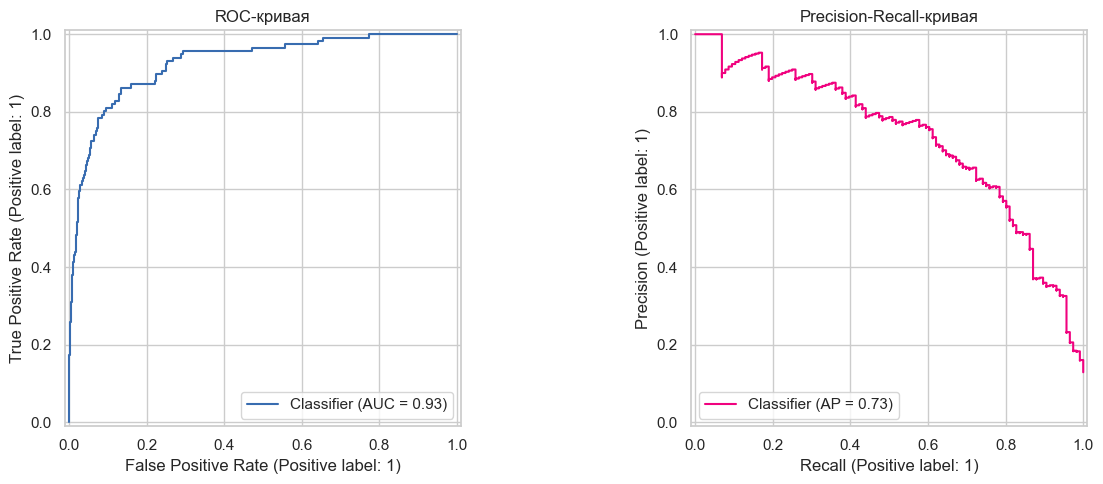

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
RocCurveDisplay.from_predictions(test_target, probability, ax=axes[0], color="#386cb0")
axes[0].set_title("ROC-кривая")
PrecisionRecallDisplay.from_predictions(test_target, probability, ax=axes[1], color="#f0027f")
axes[1].set_title("Precision-Recall-кривая")
plt.tight_layout()
plt.show()

## Матрицы ошибок

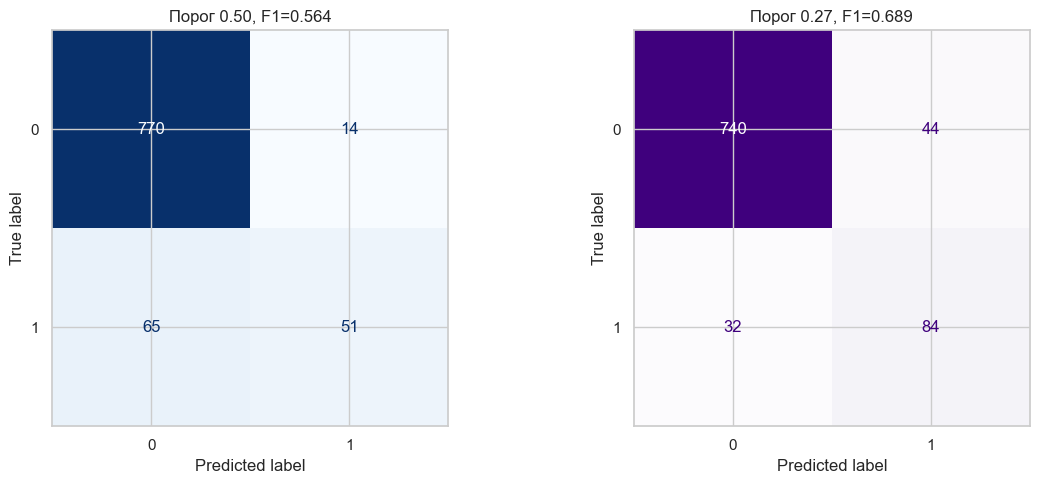

In [6]:
default_prediction = (probability >= 0.5).astype(int)
optimized_prediction = (probability >= best_row["threshold"]).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(test_target, default_prediction, ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Порог 0.50, F1={f1_score(test_target, default_prediction):.3f}")
ConfusionMatrixDisplay.from_predictions(test_target, optimized_prediction, ax=axes[1], cmap="Purples", colorbar=False)
axes[1].set_title(f"Порог {best_row['threshold']:.2f}, F1={f1_score(test_target, optimized_prediction):.3f}")
plt.tight_layout()
plt.show()

## Вывод

Порог 0.5 не всегда оптимален. Для редкого положительного класса Precision-Recall-кривая обычно информативнее ROC, а рабочий порог выбирают исходя из стоимости false positive и false negative.

## Расширенный анализ порогов и дисбаланса

In [7]:
from sklearn.calibration import CalibrationDisplay
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, learning_curve

### Baseline и class weights

In [8]:
comparison_models = {
    "Dummy": DummyClassifier(strategy="prior"),
    "Logistic": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=3000, random_state=42)),
    ]),
    "Logistic balanced": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(class_weight="balanced", max_iter=3000, random_state=42)),
    ]),
}

comparison_rows = []
comparison_probabilities = {}
for name, estimator in comparison_models.items():
    estimator.fit(train_features, train_target)
    model_probability = estimator.predict_proba(test_features)[:, 1]
    model_prediction = (model_probability >= 0.5).astype(int)
    comparison_probabilities[name] = model_probability
    comparison_rows.append({
        "model": name,
        "accuracy": accuracy_score(test_target, model_prediction),
        "precision": precision_score(test_target, model_prediction, zero_division=0),
        "recall": recall_score(test_target, model_prediction, zero_division=0),
        "f1": f1_score(test_target, model_prediction, zero_division=0),
        "roc_auc": roc_auc_score(test_target, model_probability),
    })

comparison_results = pd.DataFrame(comparison_rows).set_index("model")
comparison_results

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Dummy,0.871111,0.000000,0.000000,0.000000,0.500000
Logistic,0.912222,0.784615,0.439655,0.563536,0.926042
Logistic balanced,0.844444,0.446903,0.870690,0.590643,0.924305


### Распределение вероятностей по классам

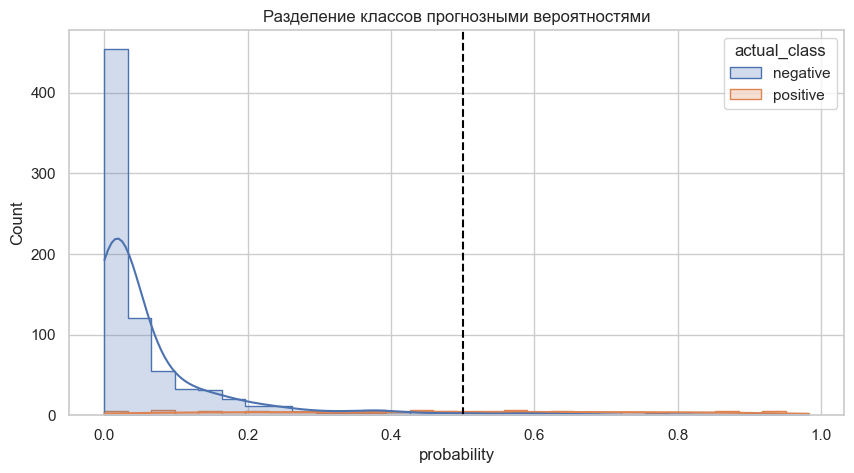

In [9]:
probability_frame = pd.DataFrame({
    "probability": probability,
    "actual_class": pd.Series(test_target).map({0: "negative", 1: "positive"}).to_numpy(),
})

plt.figure(figsize=(10, 5))
sns.histplot(data=probability_frame, x="probability", hue="actual_class", bins=30, kde=True, element="step")
plt.axvline(0.5, linestyle="--", color="black")
plt.title("Разделение классов прогнозными вероятностями")
plt.show()

### Сценарии выбора порога

In [10]:
scenario_rows = []
for threshold in [0.1, 0.2, 0.3, 0.5, float(best_row["threshold"]), 0.7, 0.9]:
    threshold_prediction = (probability >= threshold).astype(int)
    scenario_rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(test_target, threshold_prediction),
        "precision": precision_score(test_target, threshold_prediction, zero_division=0),
        "recall": recall_score(test_target, threshold_prediction, zero_division=0),
        "f1": f1_score(test_target, threshold_prediction, zero_division=0),
        "predicted_positive": int(threshold_prediction.sum()),
    })

pd.DataFrame(scenario_rows).drop_duplicates("threshold").sort_values("threshold")

,threshold,accuracy,precision,recall,f1,predicted_positive
0,0.100000,0.812222,0.396078,0.870690,0.544474,255
1,0.200000,0.895556,0.567901,0.793103,0.661871,162
4,0.266475,0.915556,0.656250,0.724138,0.688525,128
2,0.300000,0.915556,0.666667,0.689655,0.677966,120
3,0.500000,0.912222,0.784615,0.439655,0.563536,65
5,0.700000,0.900000,0.906250,0.250000,0.391892,32
6,0.900000,0.878889,0.888889,0.068966,0.128000,9


### Минимизация бизнес-стоимости

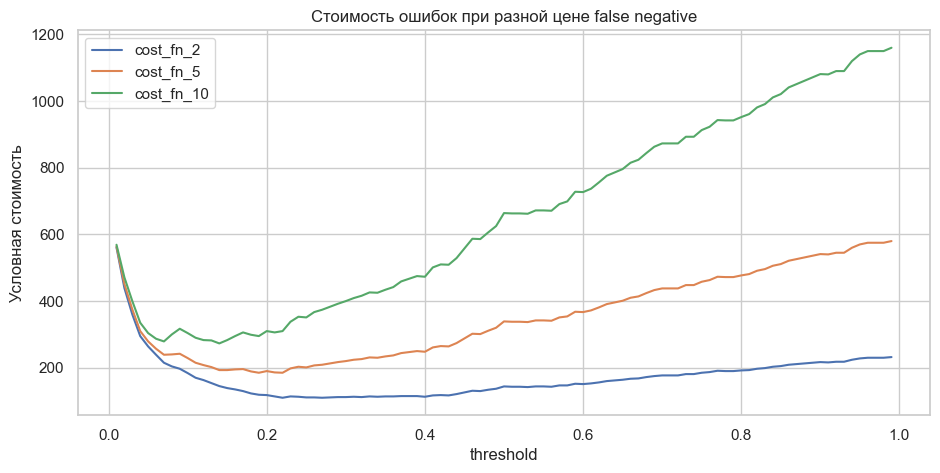

In [11]:
cost_rows = []
for threshold in np.linspace(0.01, 0.99, 99):
    threshold_prediction = (probability >= threshold).astype(int)
    false_positive = int(((test_target == 0) & (threshold_prediction == 1)).sum())
    false_negative = int(((test_target == 1) & (threshold_prediction == 0)).sum())
    cost_rows.append({
        "threshold": threshold,
        "cost_fn_2": false_positive + 2 * false_negative,
        "cost_fn_5": false_positive + 5 * false_negative,
        "cost_fn_10": false_positive + 10 * false_negative,
    })

cost_frame = pd.DataFrame(cost_rows)
cost_frame.set_index("threshold").plot(figsize=(11, 5))
plt.title("Стоимость ошибок при разной цене false negative")
plt.ylabel("Условная стоимость")
plt.show()

### Калибровка и learning curve

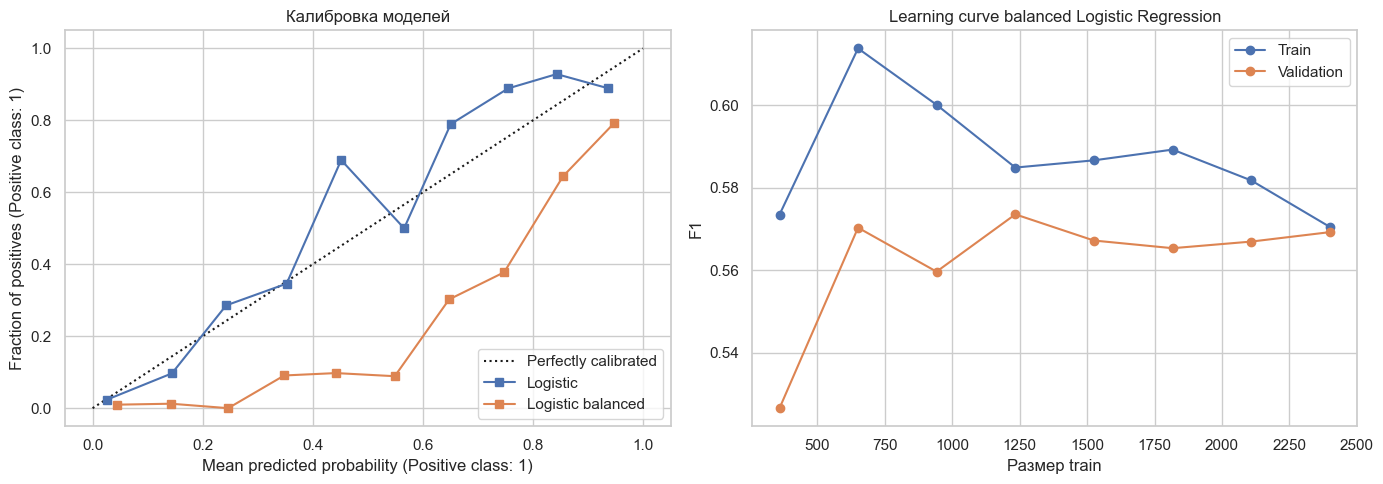

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, model_probability in comparison_probabilities.items():
    if name != "Dummy":
        CalibrationDisplay.from_predictions(test_target, model_probability, n_bins=10, name=name, ax=axes[0])
axes[0].set_title("Калибровка моделей")

validation = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
sizes, train_scores, validation_scores = learning_curve(
    comparison_models["Logistic balanced"],
    features,
    target,
    cv=validation,
    scoring="f1",
    train_sizes=np.linspace(0.15, 1.0, 8),
)
axes[1].plot(sizes, train_scores.mean(axis=1), marker="o", label="Train")
axes[1].plot(sizes, validation_scores.mean(axis=1), marker="o", label="Validation")
axes[1].set_title("Learning curve balanced Logistic Regression")
axes[1].set_xlabel("Размер train")
axes[1].set_ylabel("F1")
axes[1].legend()
plt.tight_layout()
plt.show()

### Classification report при выбранном пороге

In [13]:
optimized_prediction = (probability >= best_row["threshold"]).astype(int)
pd.DataFrame(classification_report(test_target, optimized_prediction, output_dict=True)).T

,precision,recall,f1-score,support
0,0.958549,0.943878,0.951157,784.000000
1,0.656250,0.724138,0.688525,116.000000
accuracy,0.915556,0.915556,0.915556,0.915556
macro avg,0.807400,0.834008,0.819841,900.000000
weighted avg,0.919586,0.915556,0.917306,900.000000


### Итог расширенного анализа

При дисбалансе accuracy может скрывать слабое качество редкого класса. Class weights меняют границу решения, а порог следует выбирать под бизнес-стоимость ошибок. Отдельно нужно контролировать калибровку, если вероятности используются для ранжирования или расчёта риска.